<a href="https://colab.research.google.com/github/Ololade117/stat4datascience/blob/main/w3n1_inferential_stats_confidence_intervals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics and Quantitative Methods for Data Science
[© Silvadew Institute](https://institute.silvadew.com/course-details/?c=43177d50)

# Lecture 5 — Inferential Statistics & Confidence Intervals
### Statistics & Quantitative Methods for Data Science

**Where we've been:** Weeks 1-2 covered *descriptive* statistics (summarizing data we have) and probability foundations (distributions, sampling, the CLT).

**Where we're going:** *Inferential* statistics — using a **sample** to draw conclusions about a **population** we can't fully observe, and being honest about how uncertain those conclusions are.

**This notebook:**
1. Descriptive vs. inferential statistics
2. Point estimates
3. Confidence intervals for a mean
4. Confidence intervals for a proportion
5. What "95% confidence" actually means (simulation)
6. Sample size & margin of error
7. Exercises


## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True

TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(TITANIC_URL)
titanic.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


---
# 1. Descriptive vs. inferential statistics

| | Descriptive | Inferential |
|---|---|---|
| Question | "What does *this* data look like?" | "What can I conclude about the *population* from this sample?" |
| Tools | mean, median, std, histograms | confidence intervals, hypothesis tests, p-values |
| Certainty | Exact (it's just arithmetic on data you have) | Always comes with **uncertainty** — a margin of error |

The 891 Titanic passengers in our dataset are themselves a **sample** of "everyone who could conceivably have been on a similar ship." Every number we compute from them is an *estimate*, not a certainty.

---
# 2. Point estimates

A **point estimate** is a single number used to estimate a population parameter — e.g. the sample mean $\bar{x}$ estimates the population mean $\mu$.

The problem: a point estimate alone doesn't tell you *how much to trust it*. Two samples of very different sizes could give the exact same mean, but the larger one deserves more confidence.

In [ ]:
fare = titanic['fare'].dropna()
age = titanic['age'].dropna()

print(f"Point estimate — mean fare: {fare.mean():.2f}")
print(f"Point estimate — mean age:  {age.mean():.2f}")
print(f"Point estimate — proportion survived: {titanic['survived'].mean():.3f}")

Point estimate — mean fare: 32.20
Point estimate — mean age:  29.70
Point estimate — proportion survived: 0.384


In [ ]:
# Illustrate the problem: same mean, very different sample sizes -> very different trust
np.random.seed(1)
small_sample = fare.sample(5)
large_sample = fare.sample(300)
print(f"Small sample (n=5)   mean: {small_sample.mean():.2f}, std: {small_sample.std():.2f}")
print(f"Large sample (n=300) mean: {large_sample.mean():.2f}, std: {large_sample.std():.2f}")
print("-> Point estimates alone don't show that the n=5 estimate is far less trustworthy.")

Small sample (n=5)   mean: 15.74, std: 9.50
Large sample (n=300) mean: 31.76, std: 47.49
-> Point estimates alone don't show that the n=5 estimate is far less trustworthy.


---
# 3. Confidence intervals for a mean

A **confidence interval (CI)** gives a *range* of plausible values for the population parameter, built from the point estimate plus a margin of error:

$$\bar{x} \pm t^{*}_{\alpha/2, \, n-1} \times \frac{s}{\sqrt{n}}$$

We use the **t-distribution** (not Normal) whenever the population standard deviation is unknown and estimated from the sample — which is almost always the case in practice. The t-distribution has heavier tails than Normal, which widens the interval to account for the extra uncertainty of also having estimated $s$.

In [ ]:
def mean_ci(sample, confidence=0.95):
    n = len(sample)
    x_bar = sample.mean()
    se = sample.std(ddof=1) / np.sqrt(n)
    t_star = stats.t.ppf((1 + confidence) / 2, df=n-1)
    margin = t_star * se
    return x_bar, x_bar - margin, x_bar + margin

sample_fare = fare.sample(50, random_state=3)
x_bar, lo, hi = mean_ci(sample_fare)
print(f"Sample mean fare: {x_bar:.2f}")
print(f"95% CI: [{lo:.2f}, {hi:.2f}]")
print(f"(True population mean fare, for comparison: {fare.mean():.2f})")

Sample mean fare: 37.43
95% CI: [22.00, 52.86]
(True population mean fare, for comparison: 32.20)


In [ ]:
# scipy makes this one line, once you have mean & standard error
se = stats.sem(sample_fare)
ci = stats.t.interval(0.95, df=len(sample_fare)-1, loc=sample_fare.mean(), scale=se)
print(f"scipy CI: [{ci[0]:.2f}, {ci[1]:.2f}]  (matches our hand-rolled version)")

scipy CI: [22.00, 52.86]  (matches our hand-rolled version)


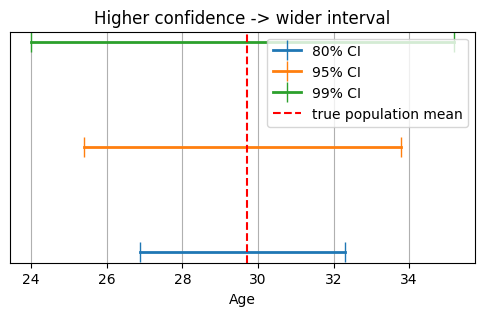

In [ ]:
# Visualize: CI for mean age, at three confidence levels
sample_age = age.sample(50, random_state=3)
fig, ax = plt.subplots(figsize=(6,3))
for i, conf in enumerate([0.80, 0.95, 0.99]):
    se_a = stats.sem(sample_age)
    lo, hi = stats.t.interval(conf, df=len(sample_age)-1, loc=sample_age.mean(), scale=se_a)
    ax.plot([lo, hi], [i, i], marker='|', markersize=15, linewidth=2, label=f'{conf:.0%} CI')
ax.axvline(age.mean(), color='red', linestyle='--', label='true population mean')
ax.set_yticks([]); ax.legend(loc='upper right'); ax.set_xlabel('Age')
ax.set_title('Higher confidence -> wider interval')
plt.show()

---
# 4. Confidence intervals for a proportion

For a proportion $\hat{p}$ (e.g. survival rate), when $n\hat{p}$ and $n(1-\hat{p})$ are both reasonably large, the Normal approximation works well:

$$\hat{p} \pm z^{*} \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

In [ ]:
def proportion_ci(successes, n, confidence=0.95):
    p_hat = successes / n
    se = np.sqrt(p_hat * (1 - p_hat) / n)
    z_star = stats.norm.ppf((1 + confidence) / 2)
    margin = z_star * se
    return p_hat, p_hat - margin, p_hat + margin

sample_titanic = titanic.sample(100, random_state=3)
n_survived = sample_titanic['survived'].sum()
n_total = len(sample_titanic)

p_hat, lo, hi = proportion_ci(n_survived, n_total)
print(f"Sample survival rate: {p_hat:.3f}")
print(f"95% CI: [{lo:.3f}, {hi:.3f}]")
print(f"(True population survival rate: {titanic['survived'].mean():.3f})")

Sample survival rate: 0.390
95% CI: [0.294, 0.486]
(True population survival rate: 0.384)


---
# 5. What does "95% confidence" actually mean?

**It does NOT mean** "there's a 95% chance the true mean is in this specific interval." Once computed, an interval either contains the true value or it doesn't — there's no probability left. It **does mean**: *if we repeated this sampling process many times, about 95% of the resulting intervals would contain the true population parameter.* Let's verify that by simulation.

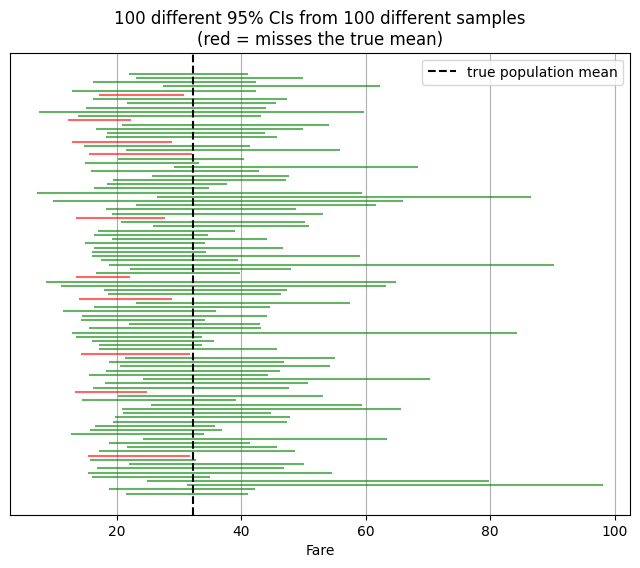

Out of 500 simulated intervals, 446 (89.2%) contained the true mean.


In [ ]:
true_mean = fare.mean()
n = 40
n_trials = 500
hits = 0
fig, ax = plt.subplots(figsize=(8, 6))

for i in range(n_trials):
    s = fare.sample(n, replace=True, random_state=i)
    se = stats.sem(s)
    lo, hi = stats.t.interval(0.95, df=n-1, loc=s.mean(), scale=se)
    contains = lo <= true_mean <= hi
    hits += contains
    if i < 100:   # only plot the first 100 for readability
        ax.plot([lo, hi], [i, i], color='green' if contains else 'red', alpha=0.6)

ax.axvline(true_mean, color='black', linestyle='--', label='true population mean')
ax.set_yticks([]); ax.set_xlabel('Fare'); ax.legend()
ax.set_title(f'100 different 95% CIs from 100 different samples\n(red = misses the true mean)')
plt.show()

print(f"Out of {n_trials} simulated intervals, {hits} ({hits/n_trials:.1%}) contained the true mean.")

---
# 6. Sample size & margin of error

Margin of error shrinks with $\sqrt{n}$ — to *halve* your margin of error, you need **4 times** as much data, not 2 times. This is why polls and studies quote sample sizes: it tells you how tight their uncertainty really is.

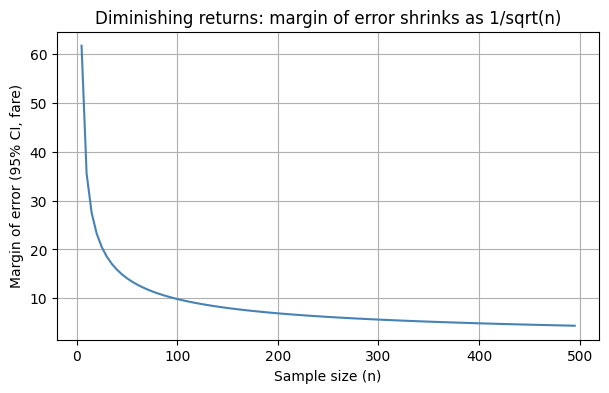

In [ ]:
fig, ax = plt.subplots(figsize=(7,4))
ns = np.arange(5, 500, 5)
margins = [stats.t.ppf(0.975, df=n-1) * fare.std() / np.sqrt(n) for n in ns]
ax.plot(ns, margins, color='steelblue')
ax.set_xlabel('Sample size (n)'); ax.set_ylabel('Margin of error (95% CI, fare)')
ax.set_title('Diminishing returns: margin of error shrinks as 1/sqrt(n)')
plt.show()

In [ ]:
# How large a sample do we need for a target margin of error on a proportion?
def required_n(margin, p_guess=0.5, confidence=0.95):
    z_star = stats.norm.ppf((1 + confidence) / 2)
    return int(np.ceil((z_star**2 * p_guess * (1-p_guess)) / margin**2))

for margin in [0.10, 0.05, 0.02, 0.01]:
    print(f"Margin of error = {margin:.0%}  ->  need n = {required_n(margin)}")
print("\n-> Halving the margin of error (0.10 -> 0.05) roughly quadruples the required sample size.")

Margin of error = 10%  ->  need n = 97
Margin of error = 5%  ->  need n = 385
Margin of error = 2%  ->  need n = 2401
Margin of error = 1%  ->  need n = 9604

-> Halving the margin of error (0.10 -> 0.05) roughly quadruples the required sample size.


---
# 7. Exercises

1. Compute a 90% confidence interval for the mean `age` using a sample of 30 passengers. How does its width compare to a 95% CI on the same sample?
2. Compute a 95% confidence interval for the proportion of passengers travelling in 3rd class, using a random sample of 150 passengers.
3. Run the "what does 95% confidence mean" simulation (Section 5) but with `n=10` instead of `n=40`. Does the empirical coverage stay close to 95%? What does this suggest about the t-distribution's small-sample correction?
4. Using `required_n`, how large a sample would you need to estimate a proportion to within a 3% margin of error at 99% confidence instead of 95%?
5. **Challenge**: The proportion CI formula in Section 4 relies on a Normal approximation that can break down for small `n` or extreme `p`. Look up the **Wilson score interval** and compare it to our simple formula for a small, skewed sample (e.g. 8 successes out of 10 trials).
